# Retail clients behaviour clustering

**Course:** Mathematical Foundations of Artificial Intelligence  
**University:** Jagiellonian University  
**Authors:** Patrycja Jaworska, Mateusz Paszyński
**Year:** 2025/2026

## Setup and Imports

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## 1. Load and cleanse Data

In [ ]:
import pandas as pd
import datetime as dt

df = pd.read_excel('data/Online Retail.xlsx')

df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df = df[~df['InvoiceNo'].astype(str).str.contains('C')] #cancelled transactions

df['TotalPrice'] = df['Quantity'] * df['UnitPrice'].round(2)

now_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (now_date - x.max()).days, # Recency: days from last order
    'InvoiceNo': 'nunique',                             # Frequency: unique invoices
    'TotalPrice': 'sum'                                 # Monetary: sum
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

rfm['Monetary'] = rfm['Monetary'].round(2)

## 2. Finding optimal number of clusters using the elbow method

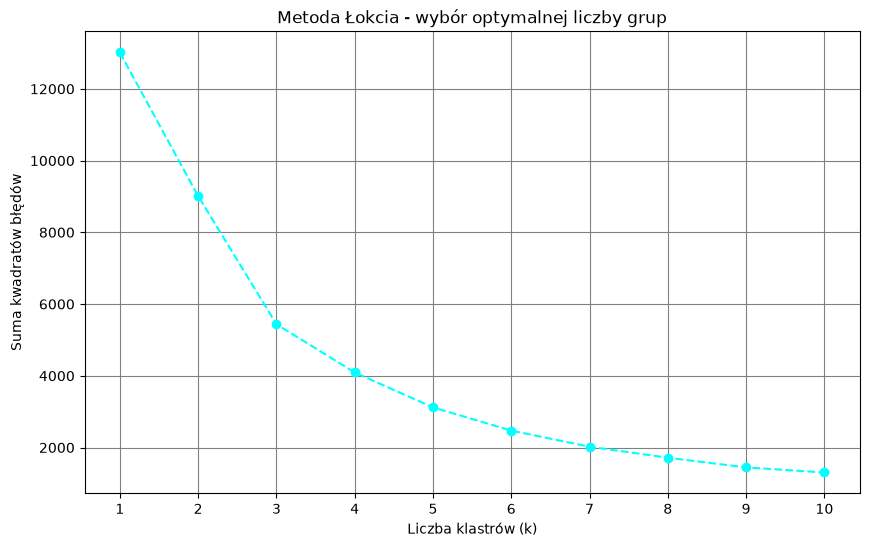

In [ ]:
properties = rfm[['Recency','Frequency','Monetary']]
scaler = StandardScaler()
properties_scaled = scaler.fit_transform(properties)

SE = []
k_range = range(1,11)

for k in k_range :
    kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)
    kmeans.fit(properties_scaled)
    SE.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, SE, marker='o', linestyle='--', color='cyan')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Suma kwadratów błędów')
plt.title('Metoda Łokcia - wybór optymalnej liczby grup')
plt.grid(True,color='grey')
plt.xticks(k_range)
plt.show()


## 3. K-Means Clustering
From image above we choose 3 as our number of clusters

In [ ]:
kmeans = KMeans(n_clusters=3,random_state=42,n_init=10)
clusters = kmeans.fit_transform(properties_scaled)

rfm['Cluster'] = kmeans.labels_
print(rfm.head())


   CustomerID  Recency  Frequency  Monetary  Cluster
0       12346      326          1  77183.60        0
1       12347        2          7   4310.00        1
2       12348       75          4   1797.24        1
3       12349       19          1   1757.55        1
4       12350      310          1    334.40        0


### Customer Profile Analysis and Business Interpretation

Based on the average RFM values, we can characterize the identified clusters as three distinct buyer personas. This segmentation allows for marketing cost optimization and tailored communication strategies.

#### Cluster 2: VIP Customers 26 customers
* **Behavioral Characteristics:** Extremely high cart value (average ~85,00$) and very high frequency (average 66 transactions). These are highly active customers who made a purchase very recently (Recency = 6 days).
* **Interpretation and Conclusions:** Despite making up a fraction of a percent of the entire database, they generate massive revenue. Most likely, these are wholesalers or B2B partners. Losing even a single customer from this group would have a significant financial impact, which is why they require an individualized approach (e.g., a dedicated account manager, exclusive VIP offers).

#### Cluster 1: Loyal Customers 3,230 customers
* **Behavioral Characteristics:** The largest group, forming the foundation of the business. They purchase quite regularly (about 4-5 transactions) and spend decent amounts (around 1,850$). Their last purchase was, on average, a little over a month ago (Recency = 41 days).
* **Interpretation and Conclusions:** This is the "healthy" tissue of the store – retail customers who trust the brand. The main analytical goal for this group should be increasing their average order value (upselling) and maintaining their loyalty through standard email marketing and reward programs.

#### Cluster 0: Lost / One-off Customers 1,082 customers
* **Behavioral Characteristics:** Very infrequent buyers (average 1.5 transactions) with the lowest cart value (about 630$). Crucially, they haven't visited the store in almost 8 months (Recency = 247 days).
* **Interpretation and Conclusions:** The "hibernating" part of the database. These are customers who probably made a one-off purchase and moved on to the competition. The store shouldn't burn its standard advertising budget on them. Instead, it's worth implementing a one-time, aggressive win-back campaign (e.g., "We miss you, here is a 20% discount" emails).

## 4. Calculating means for each property in clusters

In [ ]:
profil_klastrow = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

print(profil_klastrow)

        Recency Frequency  Monetary      
           mean      mean      mean count
Cluster                                  
0        247.11      1.58    631.42  1082
1         41.45      4.67   1855.94  3230
2          6.04     66.42  85904.35    26


## 5. Sprawdzenie stabilności podziału

In [ ]:
from sklearn.metrics import adjusted_rand_score
label_list = []
for seed in range (10):
    kmeans_temp=KMeans(n_clusters=3, random_state=seed, n_init=10)
    label_temp=kmeans_temp.fit_predict(properties_scaled)
    label_list.append(label_temp)

ari_scores=[]
for i in range(len(label_list)):
    for j in range(i+1,len(label_list)):
        score=adjusted_rand_score(label_list[i],label_list[j])
        ari_scores.append(score)

print("Average ARI score:", round(np.mean(ari_scores), 4))
print("Minimum ARI score:", round(np.min(ari_scores), 4))
print("Maximum ARI score:", round(np.max(ari_scores), 4))


Average ARI score: 0.9976
Minimum ARI score: 0.9932
Maximum ARI score: 1.0


Stabilność podziału została sprawdzona poprzez kilkukrotne uruchomienie algorytmu K-Means dla tej samej liczby klastrów, ale z różnymi wartościami random_state. Następnie wyniki zostały porównane za pomocą miary Adjusted Rand Index. Wysoka wartość ARI oznacza, że klienci są przypisywani do podobnych grup niezależnie od początkowego ustawienia algorytmu. Dzięki temu można stwierdzić, że uzyskany podział na klastry jest stabilny.

## 6. Wizualizacja segmentów klientów metodą PCA

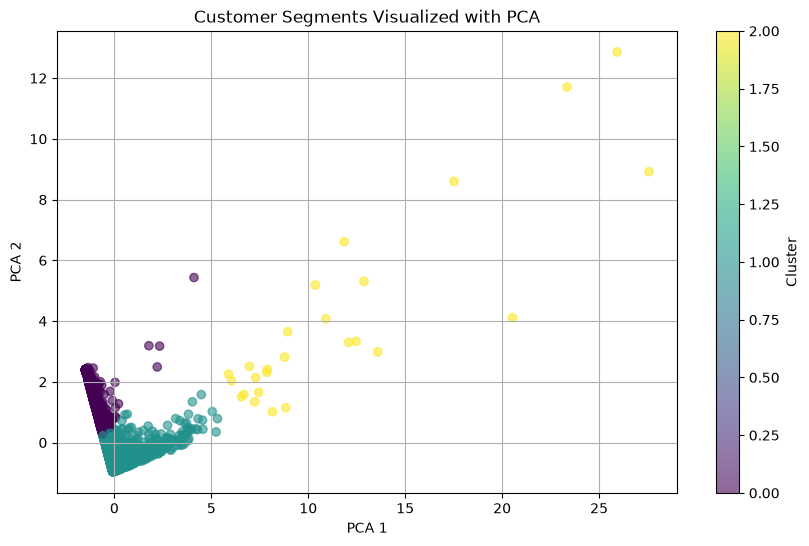

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(properties_scaled)

rfm['PCA1'] = pca_result[:, 0]
rfm['PCA2'] = pca_result[:, 1]

plt.figure(figsize=(10, 6))

plt.scatter(
    rfm['PCA1'],
    rfm['PCA2'],
    c=rfm['Cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Customer Segments Visualized with PCA')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

Metoda PCA została wykorzystana do zmniejszenia liczby wymiarów z trzech cech RFM do dwóch wymiarów. Dzięki temu możliwe było przedstawienie segmentów klientów na wykresie dwuwymiarowym. Każdy punkt oznacza jednego klienta, a kolor punktu odpowiada klastrowi przypisanemu przez algorytm K-Means. Wizualizacja pozwala ocenić, czy utworzone grupy klientów są od siebie widocznie odseparowane.

## 7. Wizualizacja segmentów klientów metodą t-SNE

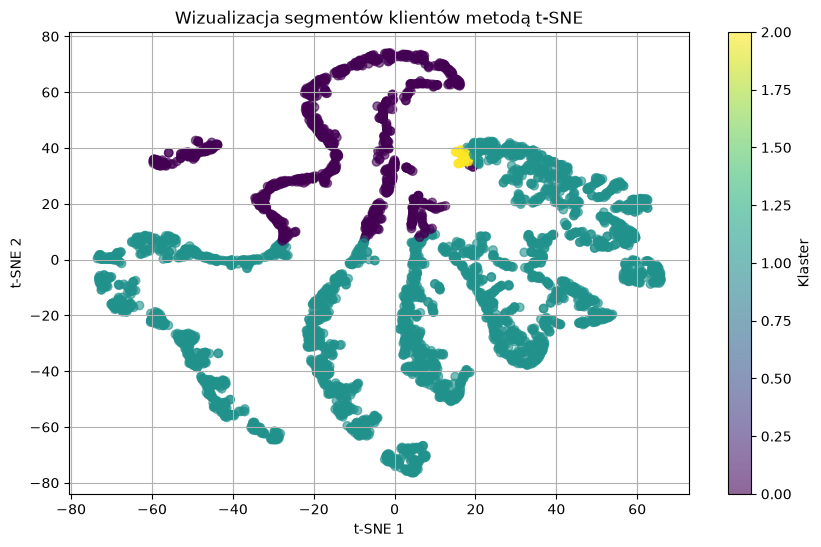

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    learning_rate='auto',
    init='pca'
)

tsne_result = tsne.fit_transform(properties_scaled)

rfm['TSNE1'] = tsne_result[:, 0]
rfm['TSNE2'] = tsne_result[:, 1]

plt.figure(figsize=(10, 6))

plt.scatter(
    rfm['TSNE1'],
    rfm['TSNE2'],
    c=rfm['Cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('Wizualizacja segmentów klientów metodą t-SNE')
plt.colorbar(label='Klaster')
plt.grid(True)
plt.show()

Metoda t-SNE została zastosowana jako dodatkowa metoda wizualizacji danych w dwóch wymiarach. W przeciwieństwie do PCA, t-SNE jest metodą nieliniową i lepiej pokazuje lokalne podobieństwa między klientami. Na wykresie każdy punkt reprezentuje jednego klienta, a kolor oznacza jego klaster. Wizualizacja pomaga sprawdzić, czy klienci należący do tego samego segmentu znajdują się blisko siebie.

## 8. Wykres radarowy segmentów klientów

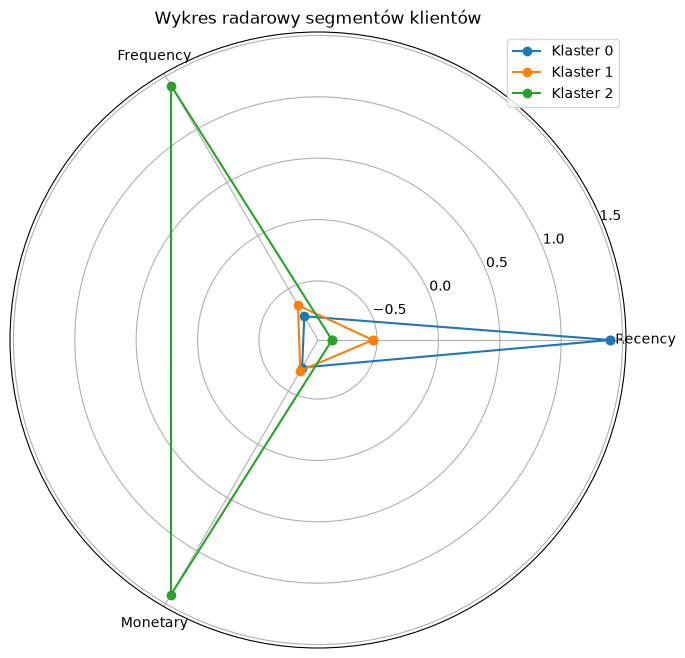

In [ ]:
cluster_profiles = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

scaler_profile = StandardScaler()

cluster_profiles_scaled = pd.DataFrame(
    scaler_profile.fit_transform(cluster_profiles),
    columns=cluster_profiles.columns,
    index=cluster_profiles.index
)

categories = list(cluster_profiles_scaled.columns)
N = len(categories)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8, 8))

for cluster in cluster_profiles_scaled.index:
    values = cluster_profiles_scaled.loc[cluster].tolist()
    values += values[:1]

    plt.polar(
        angles,
        values,
        marker='o',
        label=f'Klaster {cluster}'
    )

plt.xticks(angles[:-1], categories)
plt.title('Wykres radarowy segmentów klientów')
plt.legend()
plt.show()

Wykres radarowy przedstawia porównanie średnich wartości cech RFM dla każdego klastra. Przed narysowaniem wykresu dane zostały zestandaryzowane, ponieważ Recency, Frequency i Monetary mają różne skale. Dzięki temu można łatwiej porównać profile poszczególnych grup klientów i zauważyć, które cechy są dla nich najbardziej charakterystyczne.